# Harmonic Oscillator

This notebook solves the 1D harmonic oscillator with a neural IVP model and compares the result against an RK4 reference solution.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import json
import os
import sys

import matplotlib
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

matplotlib.rcParams["font.family"] = "Times New Roman"
matplotlib.rcParams["font.size"] = 11
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["axes.linewidth"] = 0.8
matplotlib.rcParams["xtick.major.width"] = 0.8
matplotlib.rcParams["ytick.major.width"] = 0.8

cwd = Path.cwd()
EXAMPLES_DIR = cwd if cwd.name == "examples" else cwd / "examples"
PROJECT_ROOT = EXAMPLES_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from helpers import (
    DATA_TYPE,
    DEVICE,
    SimpleMLP,
    ensure_run_dirs,
    expected_path_tensor,
    second_order_dynamics,
)

print(f"Using device: {DEVICE}")

Using device: mps


In [2]:
@dataclass(frozen=True)
class HarmonicOscillator:
    dim: int = 1

    def acceleration(self, position: torch.Tensor) -> torch.Tensor:
        return -position


def plot_trajectory(time_values, predicted, reference):
    fig = plt.figure(figsize=(6, 4), dpi=150)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111)
    ax.plot(time_values, predicted, color="black", linewidth=2, label="Neural IVP")
    ax.plot(time_values, reference, color="lightgrey", linewidth=2.5, label="RK4", zorder=-1)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x(t)$")
    ax.legend(loc="upper right", frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="in", which="both", left=True, bottom=True)
    ax.tick_params(labelbottom=True, labelleft=True)
    return fig


def plot_loss_history(loss_history):
    fig = plt.figure(figsize=(6, 4), dpi=150)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111)
    ax.semilogy(loss_history, linewidth=2, color="black")
    ax.set_xlabel(r"Epoch")
    ax.set_ylabel(r"Loss")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="in", which="both", left=True, bottom=True)
    ax.tick_params(labelbottom=True, labelleft=True)
    return fig

In [3]:
params = {
    "activation": "sechlu",
    "hidden": 64,
    "epochs": 2_000,
    "lr": 3e-3,
    "T_MIN": 0.0,
    "T_MAX": 10.0,
    "TIMESTEP": 0.05,
    "x0": 0.0,
    "v0": 1.0,
    "ODE_REGULARISER": 1.0,
    "POSITION_REGULARISER": 1.0,
    "VELOCITY_REGULARISER": 1.0,
    "JOB_ID": 1,
}

dt = params["TIMESTEP"]
steps = int(round((params["T_MAX"] - params["T_MIN"]) / dt)) + 1
time_grid = torch.linspace(
    params["T_MIN"],
    params["T_MAX"],
    steps,
    dtype=DATA_TYPE,
    device=DEVICE,
)
t = time_grid.unsqueeze(0).unsqueeze(2).requires_grad_(True)

init_position = torch.tensor([params["x0"]], dtype=DATA_TYPE, device=DEVICE)
init_velocity = torch.tensor([params["v0"]], dtype=DATA_TYPE, device=DEVICE)
system = HarmonicOscillator()
expected = expected_path_tensor(
    system,
    init_position,
    init_velocity,
    params["T_MIN"],
    params["T_MAX"],
    dt,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

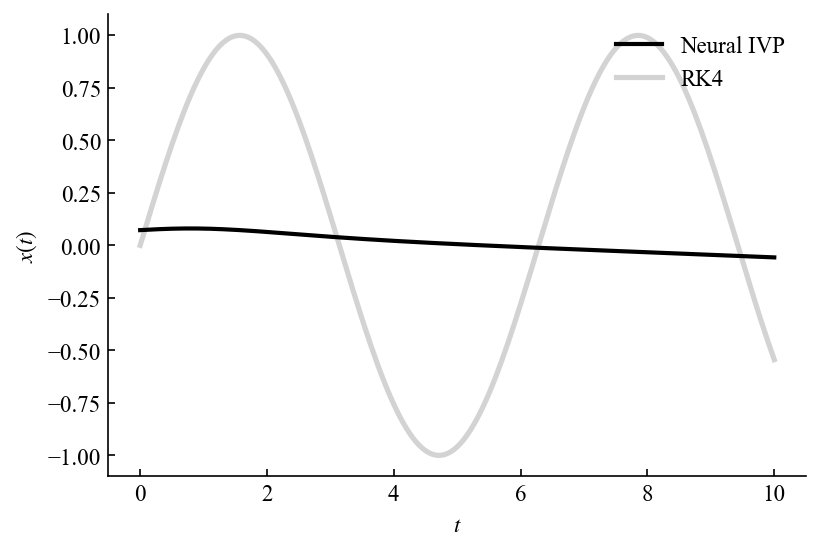

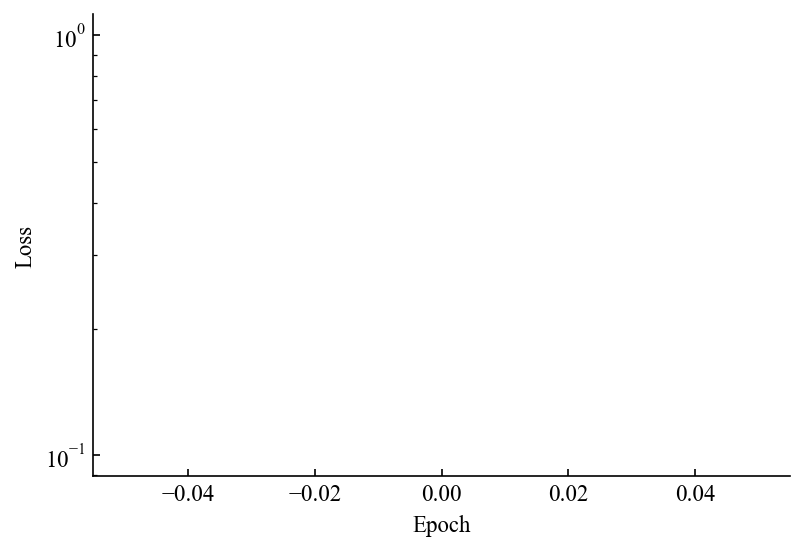

 24%|██▍       | 484/2000 [00:04<00:08, 185.30it/s]

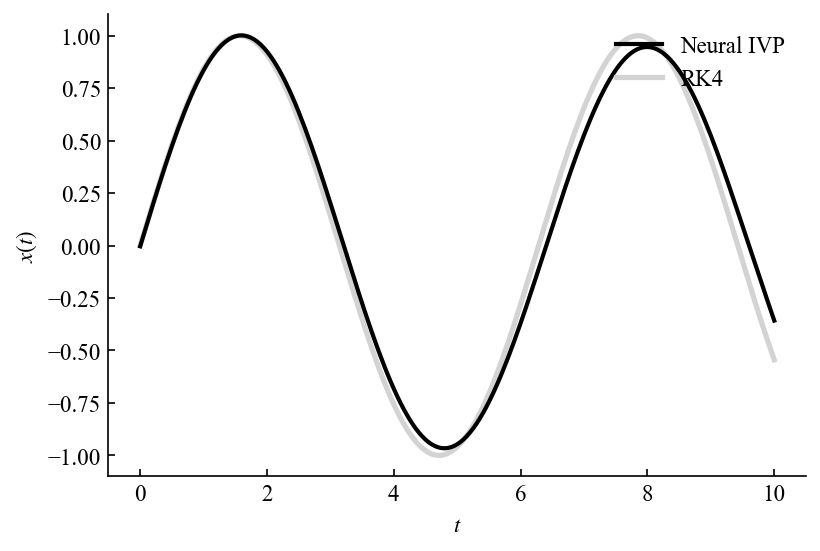

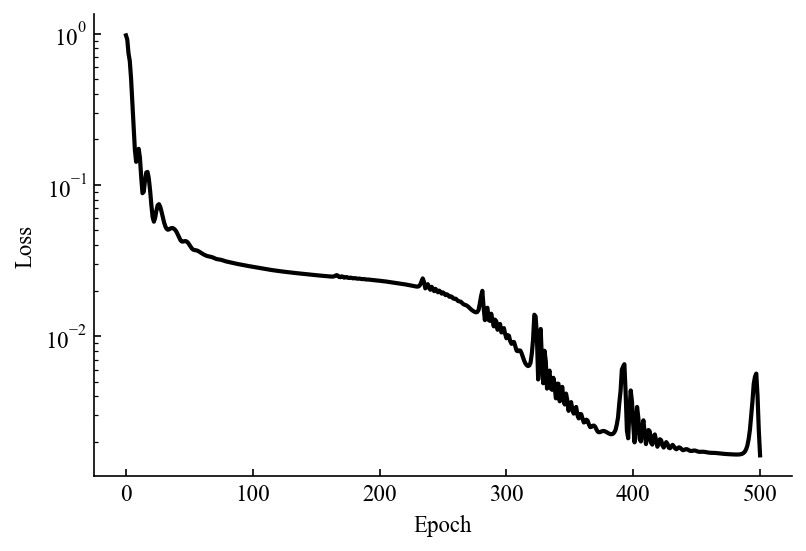

 50%|████▉     | 990/2000 [00:07<00:05, 190.34it/s]

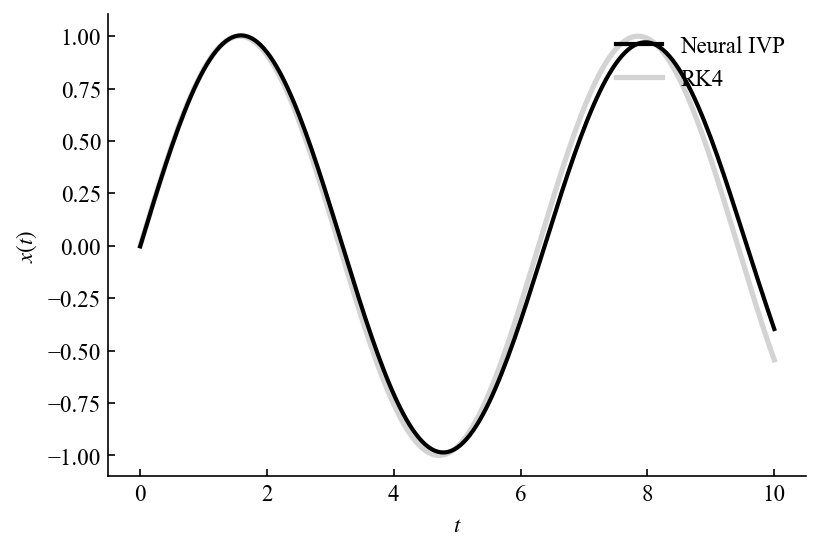

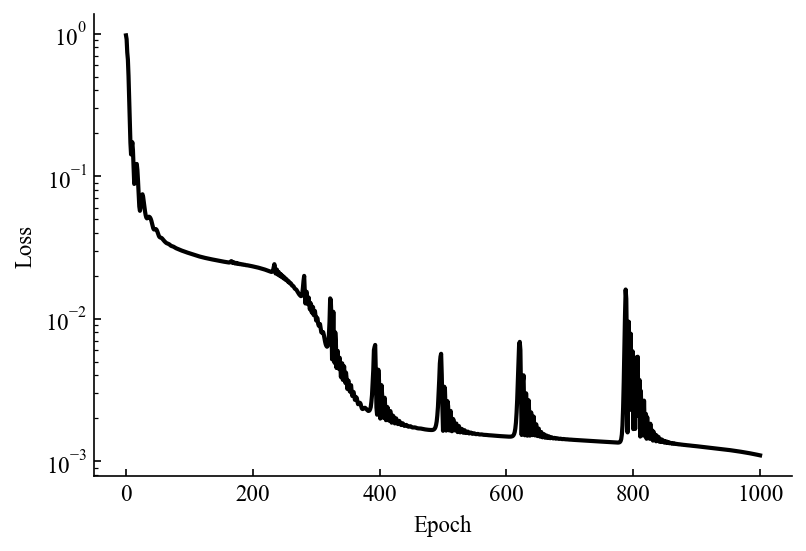

 75%|███████▍  | 1496/2000 [00:10<00:02, 185.57it/s]

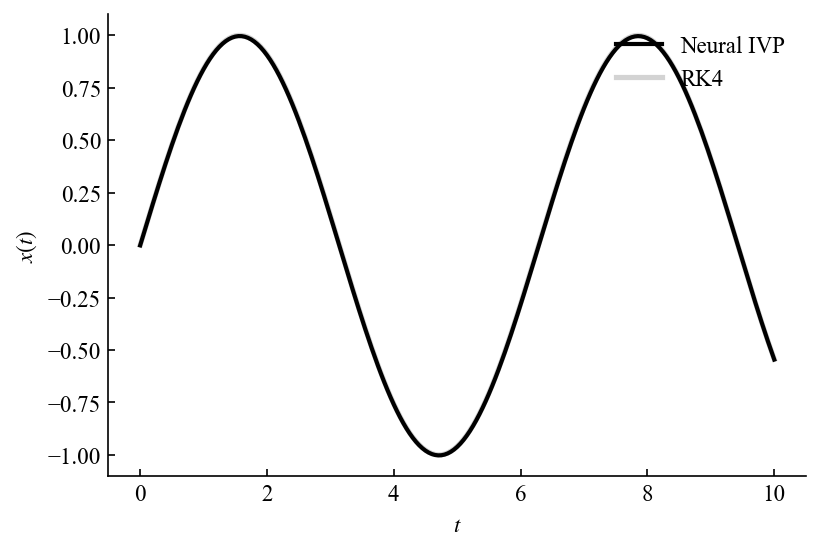

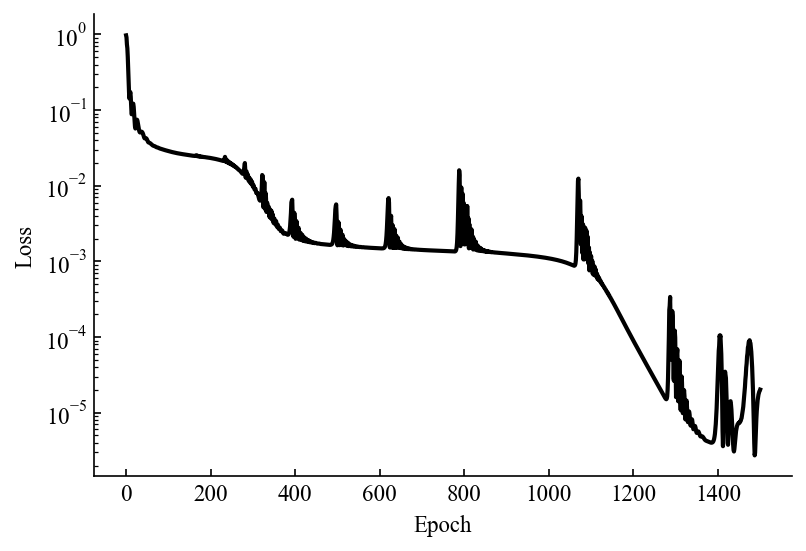

 99%|█████████▉| 1987/2000 [00:12<00:00, 190.86it/s]

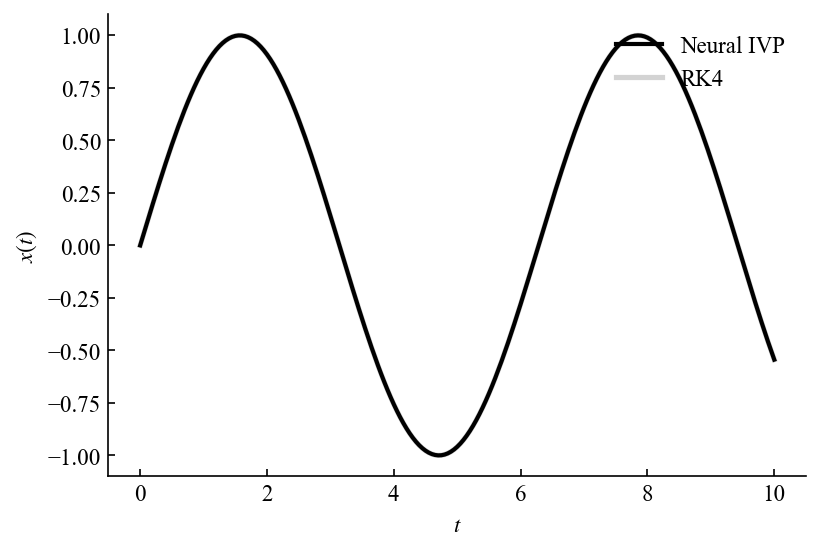

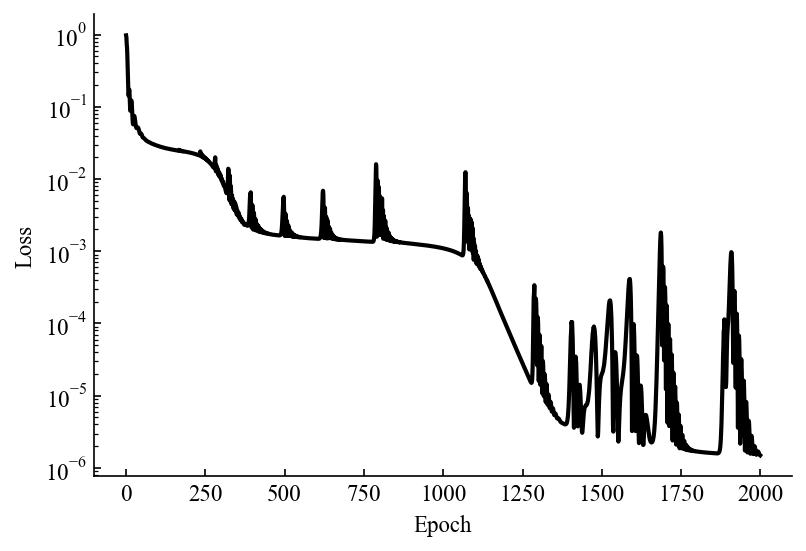

100%|██████████| 2000/2000 [00:13<00:00, 152.08it/s]


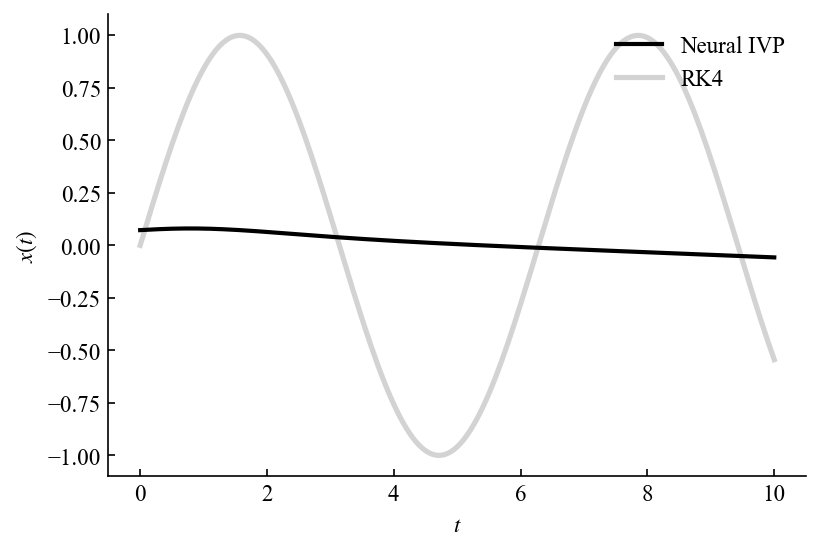

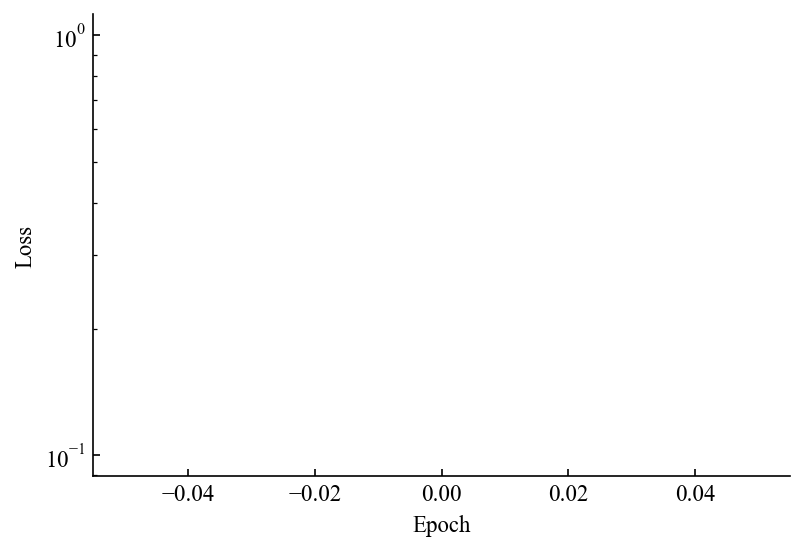

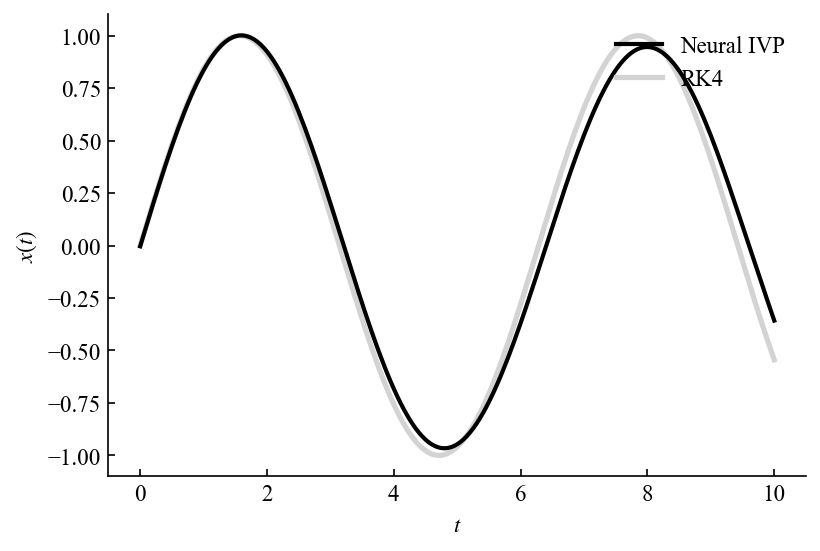

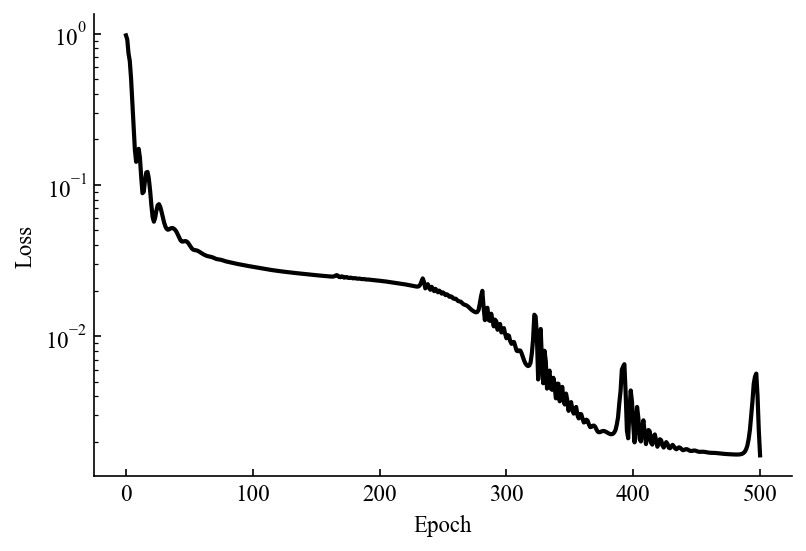

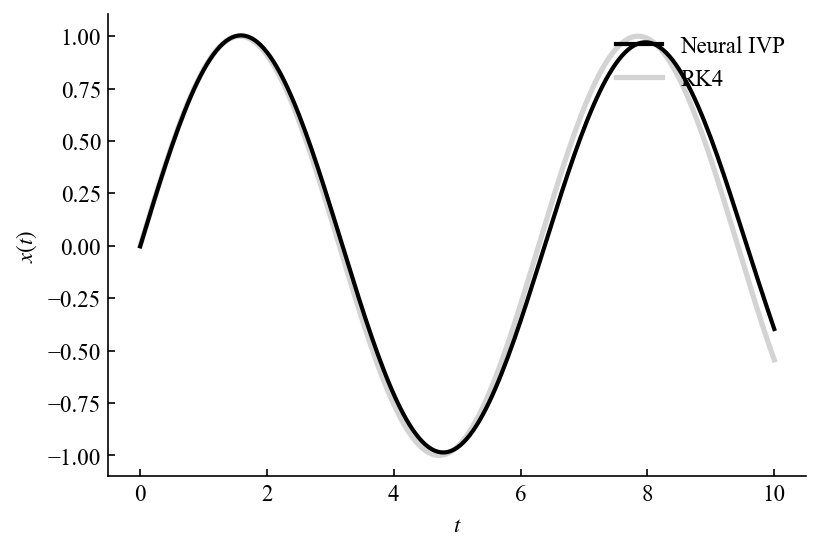

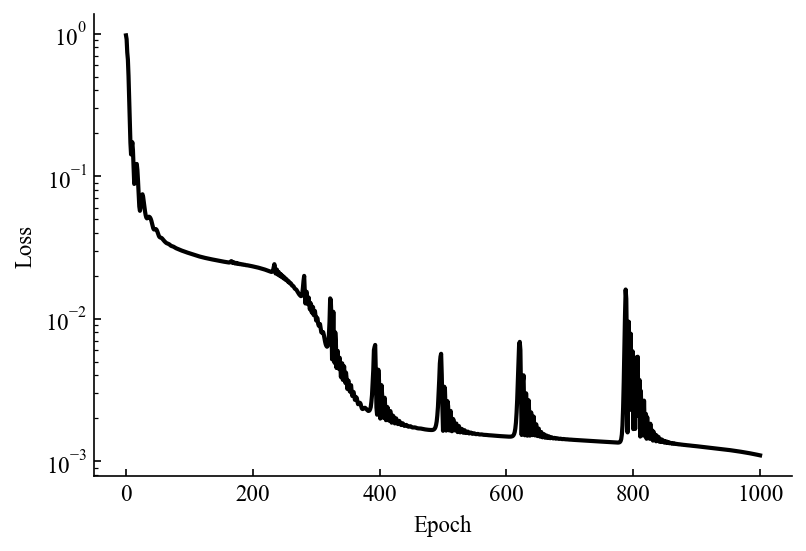

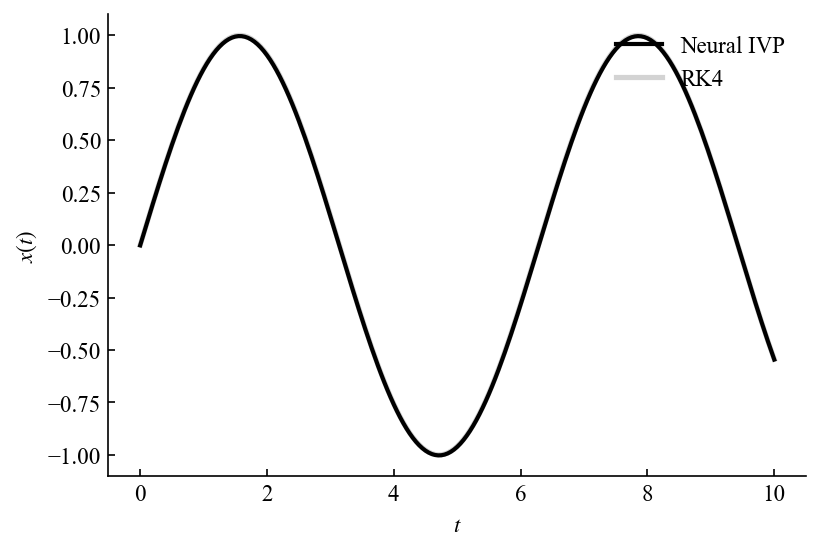

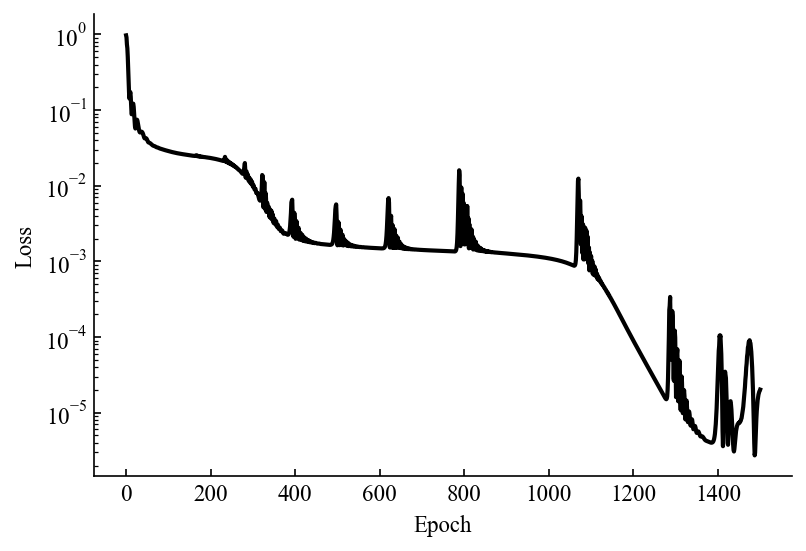

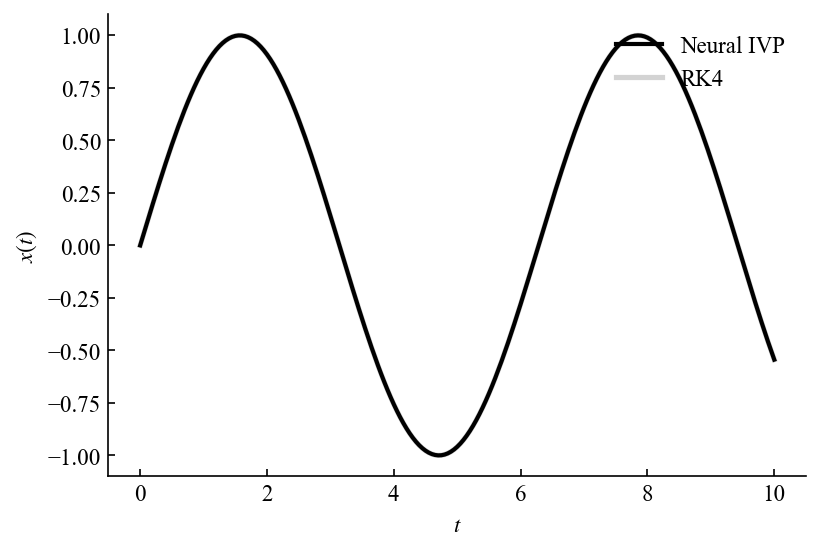

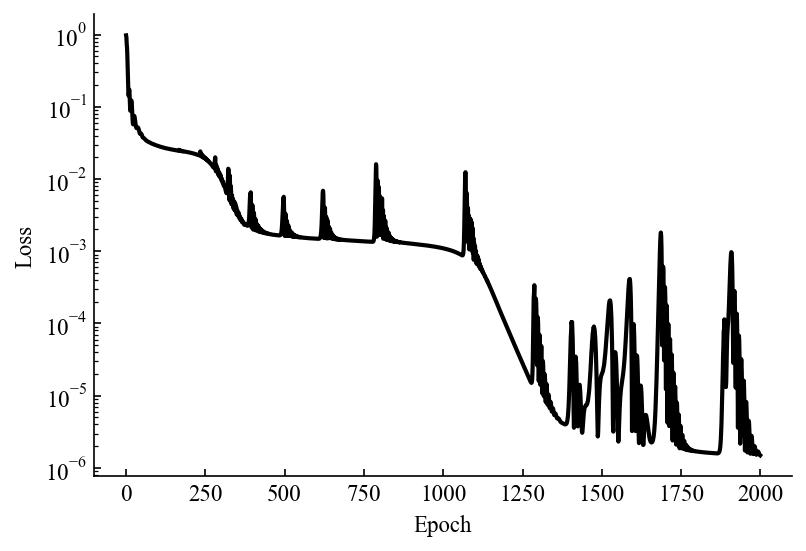

In [4]:
model_x = SimpleMLP(
    in_features=1,
    hidden=params["hidden"],
    out_features=1,
    activation=params["activation"],
).to(DEVICE)
optimiser = torch.optim.Adam(model_x.parameters(), lr=params["lr"])
loss_fn = torch.nn.MSELoss()
loss_history = []


def evaluate():
    prediction = model_x(t)
    velocities, _, residuals = second_order_dynamics(system, prediction, t)
    position_loss = loss_fn(prediction[:, 0, :], init_position.unsqueeze(0))
    velocity_loss = loss_fn(velocities[:, 0, :], init_velocity.unsqueeze(0))
    ode_loss = loss_fn(residuals, torch.zeros_like(residuals))
    total_loss = (
        params["ODE_REGULARISER"] * ode_loss
        + params["POSITION_REGULARISER"] * position_loss
        + params["VELOCITY_REGULARISER"] * velocity_loss
    )
    return prediction, total_loss


for epoch in tqdm(range(params["epochs"])):
    prediction, total_loss = evaluate()
    optimiser.zero_grad()
    total_loss.backward()
    optimiser.step()
    loss_history.append(total_loss.item())

    if epoch % 500 == 0 or epoch == params["epochs"] - 1:
        time_values = t[0, :, 0].detach().cpu().numpy()
        predicted_values = prediction[0, :, 0].detach().cpu().numpy()
        reference_values = expected[0, :, 0].detach().cpu().numpy()
        display(plot_trajectory(time_values, predicted_values, reference_values))
        display(plot_loss_history(loss_history))

final_prediction, _ = evaluate()

Saved:
- Model: /Users/jack/Research/neural-ivp/examples/outputs/models/harmonic_oscillator_a8601507/1_x.pth
- Loss history: /Users/jack/Research/neural-ivp/examples/outputs/paths/harmonic_oscillator_a8601507/loss_history.json
- Trajectory: /Users/jack/Research/neural-ivp/examples/outputs/figures/harmonic_oscillator_a8601507/trajectory.png
- Loss plot: /Users/jack/Research/neural-ivp/examples/outputs/figures/harmonic_oscillator_a8601507/loss_history.png


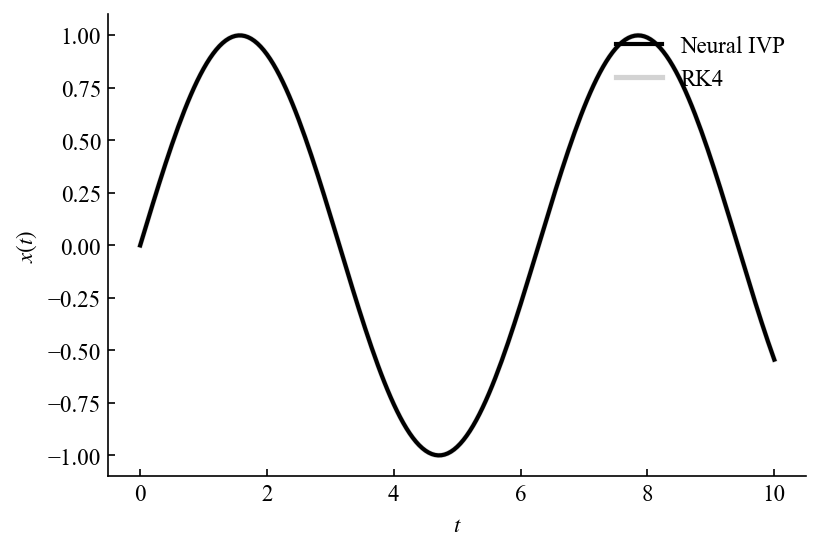

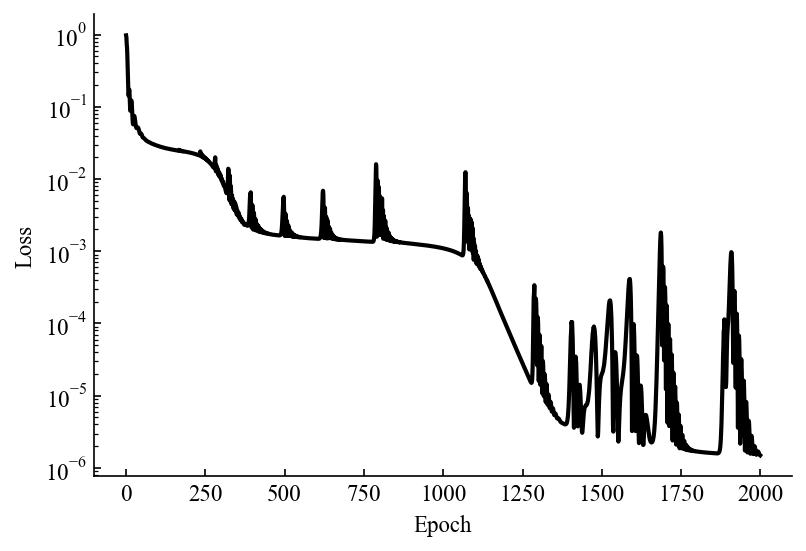

In [5]:
output_base = EXAMPLES_DIR / "outputs"
paths = ensure_run_dirs(str(output_base), params, system_name="harmonic_oscillator")
model_path = os.path.join(paths["models"], f"{params['JOB_ID']}_x.pth")
loss_history_path = os.path.join(paths["paths"], "loss_history.json")
trajectory_path = os.path.join(paths["figures"], "trajectory.png")
loss_plot_path = os.path.join(paths["figures"], "loss_history.png")

torch.save(model_x, model_path)
with open(loss_history_path, "w") as handle:
    json.dump(loss_history, handle)

time_values = t[0, :, 0].detach().cpu().numpy()
predicted_values = final_prediction[0, :, 0].detach().cpu().numpy()
reference_values = expected[0, :, 0].detach().cpu().numpy()

trajectory_figure = plot_trajectory(time_values, predicted_values, reference_values)
trajectory_figure.savefig(trajectory_path, dpi=150, bbox_inches="tight")
loss_figure = plot_loss_history(loss_history)
loss_figure.savefig(loss_plot_path, dpi=150, bbox_inches="tight")

print("Saved:")
print(f"- Model: {model_path}")
print(f"- Loss history: {loss_history_path}")
print(f"- Trajectory: {trajectory_path}")
print(f"- Loss plot: {loss_plot_path}")